# 09 · Value-at-Risk backtest: do better forecasts make better risk limits?

Steps 5 to 9 judged the models on statistical losses. This notebook puts the forecasts to work in the application that banks and regulators care about: the **Value-at-Risk** (VaR).

The **1-day VaR at 99%** of a position is the loss that should be exceeded on only 1 day out of 100. It sets trading limits and, under the Basel rules, the capital a bank must hold. A day on which the loss exceeds the VaR is a **violation**.

**Backtesting** a VaR means checking the promise against what happened: over 20 years and 59 series, were there 1% of violations, no more and no fewer?

1. From a volatility forecast to a VaR
2. Are returns normal once divided by the forecast volatility?
3. Is the number of violations right? The Kupiec test
4. Same number of violations, different quality: the size of the VaR and the quantile loss
5. Do violations come in clusters? The Christoffersen test
6. What would the regulator say? The Basel traffic light
7. Is the most accurate model the safest one in a crisis?

**Run first** (from the project root, about a minute):
```bash
python -m src.data.setup_db              # adds the result tables
python -m src.risk.run_var_backtest
```

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.stats import binom

from src.db import get_engine
from src.risk.var import historical_simulation, load_var_data, standardised_returns, value_at_risk
from src.viz import AQUA, BLUE, GRID, INK, INK_2, MUTED, ORANGE, SURFACE, save, set_style

set_style()
engine = get_engine()
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:,.2f}".format)

LABELS = {"naive": "Naive (last value)", "monthly_average": "Monthly average", "historical_mean": "Historical mean",
          "ewma": "EWMA of range-based variance", "riskmetrics": "RiskMetrics (EWMA of squared returns)",
          "garch": "GARCH(1,1)", "gjr_garch": "GJR-GARCH", "har": "HAR", "har_x": "HAR-X",
          "lgbm": "LightGBM", "lgbm_hybrid": "HAR-X + LightGBM", "lstm": "LSTM", "transformer": "Transformer",
          "ensemble_mean": "Ensemble (mean of 5)", "ensemble_median": "Ensemble (median of 5)",
          "historical_simulation": "Historical simulation (no volatility model)"}
FAMILIES = {"ensemble": ("Combinations", INK), "deep_learning": ("Deep learning", AQUA),
            "machine_learning": ("Machine learning", ORANGE), "econometric": ("Econometric models", BLUE),
            "baseline": ("Baselines", MUTED), "benchmark": ("Historical simulation", "#8a5fbf")}
HS = "historical_simulation"
DIVERGING = LinearSegmentedColormap.from_list("few_many", [BLUE, "#e9e8e4", ORANGE])     # blue = too few violations, orange = too many

overall = pd.read_sql("SELECT * FROM var_backtest_overall", engine)
overall["family"] = overall["family"].fillna("benchmark")
tests = pd.read_sql("SELECT * FROM var_tests", engine)
yearly = pd.read_sql("SELECT * FROM var_backtest_yearly", engine)

def results(method, confidence, benchmark=True):
    # One row per model for a quantile method and a confidence level; the benchmark is added at the bottom
    keep = (overall["confidence"] == confidence) & ((overall["method"] == method) | (benchmark & (overall["model"] == HS)))
    return overall[keep].sort_values("quantile_loss").set_index("model")

ranking = results("empirical", 99, benchmark=False).index.tolist()        # order used in the tables and charts
print(f"{int(overall['n'].iloc[0]):,} daily returns per model, {int(overall['n_series'].iloc[0])} series, "
      f"{yearly['year'].min()} to {yearly['year'].max()}")

293,336 daily returns per model, 59 series, 2007 to 2026


## 1. From a volatility forecast to a VaR

Every model of this project forecasts tomorrow's **variance**. Its square root is the forecast volatility: the typical size of tomorrow's move. The VaR is a multiple of it:

> **VaR(tomorrow) = multiplier × forecast volatility(tomorrow)**

The multiplier answers the question "how many volatilities away is a 1-in-100 loss?". Two answers are compared:

* **Normal:** if returns followed the normal (bell-shaped) distribution, the answer would be 2.33 volatilities at 99% and 1.64 at 95%. This is the textbook formula.
* **Empirical:** look at the past. Divide each past return by the volatility that the model had forecast for that day (a **standardised return**), and take the 1% worst of them as the multiplier. This is called *filtered historical simulation*. The multiplier is re-estimated once a year for each series, on earlier years only; the first test year (2006) only serves to estimate the first multipliers, so the backtest runs from 2007.

A benchmark that uses no volatility model at all is added: **historical simulation**, the 1% worst return of the last 250 days. It is simple and still widely used by banks.

The chart shows the two approaches on the Euro Stoxx 50 around the COVID-19 crash. Bars are daily returns; a bar that crosses a line is a violation of that VaR.

99% VaR from the HAR-X forecast: 11 violations in 314 days (expected: 3.1), average VaR 3.6%
99% VaR by historical simulation: 10 violations in 314 days (expected: 3.1), average VaR 4.5%


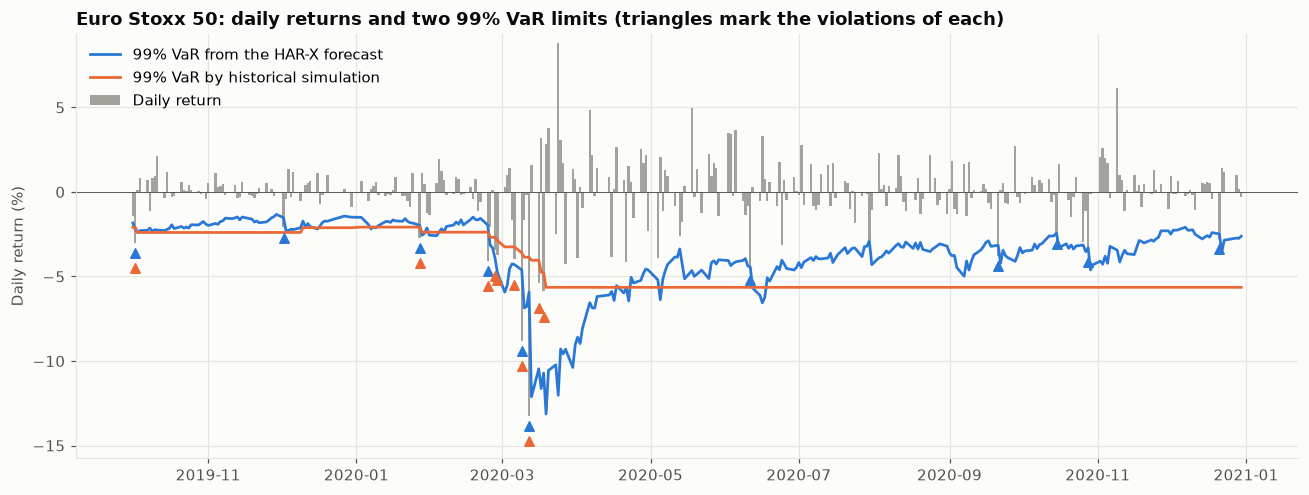

In [ ]:
data, models = load_var_data(engine)
returns = pd.read_sql("SELECT ticker, date, ret_d FROM features ORDER BY ticker, date", engine, parse_dates=["date"])

ticker, start, end = "^STOXX50E", "2019-10-01", "2020-12-31"
harx_var = value_at_risk(data, "har_x", "empirical", 99)
simulated = historical_simulation(returns, 99)
example = data.assign(model_var=harx_var).merge(simulated.rename(columns={"var": "hs_var"}), on=["ticker", "date"], how="left")
example = example[(example["ticker"] == ticker) & example["return_date"].between(start, end)].set_index("return_date")

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.bar(example.index, example["next_ret"] * 100, width=1.0, color=MUTED, label="Daily return")
for column, color, label, offset in [("model_var", BLUE, "99% VaR from the HAR-X forecast", 0.6),
                                     ("hs_var", ORANGE, "99% VaR by historical simulation", 1.5)]:
    ax.plot(example.index, -example[column] * 100, color=color, lw=1.8, label=label)
    hits = example[example["next_ret"] < -example[column]]
    ax.scatter(hits.index, hits["next_ret"] * 100 - offset, marker="^", s=38, color=color, zorder=3)
    print(f"{label}: {len(hits)} violations in {len(example)} days (expected: {len(example) * 0.01:.1f}), "
          f"average VaR {example[column].mean():.1%}")
ax.axhline(0, color=INK_2, lw=0.6)
ax.set_ylabel("Daily return (%)")
ax.set_ylim(example["next_ret"].min() * 100 - 2.5, example["next_ret"].max() * 100 + 0.5)
ax.set_title("Euro Stoxx 50: daily returns and two 99% VaR limits (triangles mark the violations of each)")
ax.legend(loc="upper left")
fig.tight_layout()
save(fig, "10_var_example")
plt.show()

**Reading the chart.** These fifteen months contain the fastest crash of the sample, and neither limit kept its promise: 11 violations for the HAR-X limit and 10 for historical simulation, against 3 expected. The difference is in how they failed.

* **Historical simulation (orange) is flat.** It stays between 2 and 2.5% until late February, so eight of its ten violations fall within four weeks (24 February to 18 March). Then, having finally recorded the crash, it stays at 5.6% until the end of the year, long after the danger has passed.
* **The HAR-X limit (blue) follows the market.** It goes from 1.3% in the calmest weeks to 13% at the peak, and comes back to about 4% from April. It is violated three times during the crash; its other violations are isolated days spread over the year.
* **It also ties up less capital:** 3.6% of the position on average, against 4.5%.

One window proves nothing. The rest of the notebook counts over 20 years and 59 series.

## 2. Are returns normal once divided by the forecast volatility?

If a model forecasts volatility perfectly **and** returns are normal, the standardised returns have a standard deviation of 1, and 1% of them fall below -2.33. The table checks both for a few models.

In [ ]:
rows = {}
for model in ["har_x", "ensemble_mean", "transformer", "gjr_garch", "riskmetrics"]:
    z = standardised_returns(data, model)
    rows[LABELS[model]] = {"standard deviation": z.std(), "5% quantile": z.quantile(0.05), "1% quantile": z.quantile(0.01),
                           "below -2.33 (%)": (z < -2.326).mean() * 100, "below -4 (%)": (z < -4).mean() * 100}
rows["Normal distribution"] = {"standard deviation": 1.0, "5% quantile": -1.645, "1% quantile": -2.326,
                               "below -2.33 (%)": 1.0, "below -4 (%)": 0.003}
display(pd.DataFrame(rows).T.round(3))

,standard deviation,5% quantile,1% quantile,below -2.33 (%),below -4 (%)
HAR-X,1.01,-1.61,-2.67,1.64,0.22
Ensemble (mean of 5),1.01,-1.63,-2.69,1.69,0.21
Transformer,1.02,-1.64,-2.72,1.76,0.22
GJR-GARCH,1.00,-1.59,-2.70,1.64,0.23
RiskMetrics (EWMA of squared returns),1.07,-1.69,-2.90,2.05,0.32
Normal distribution,1.00,-1.65,-2.33,1.00,0.00


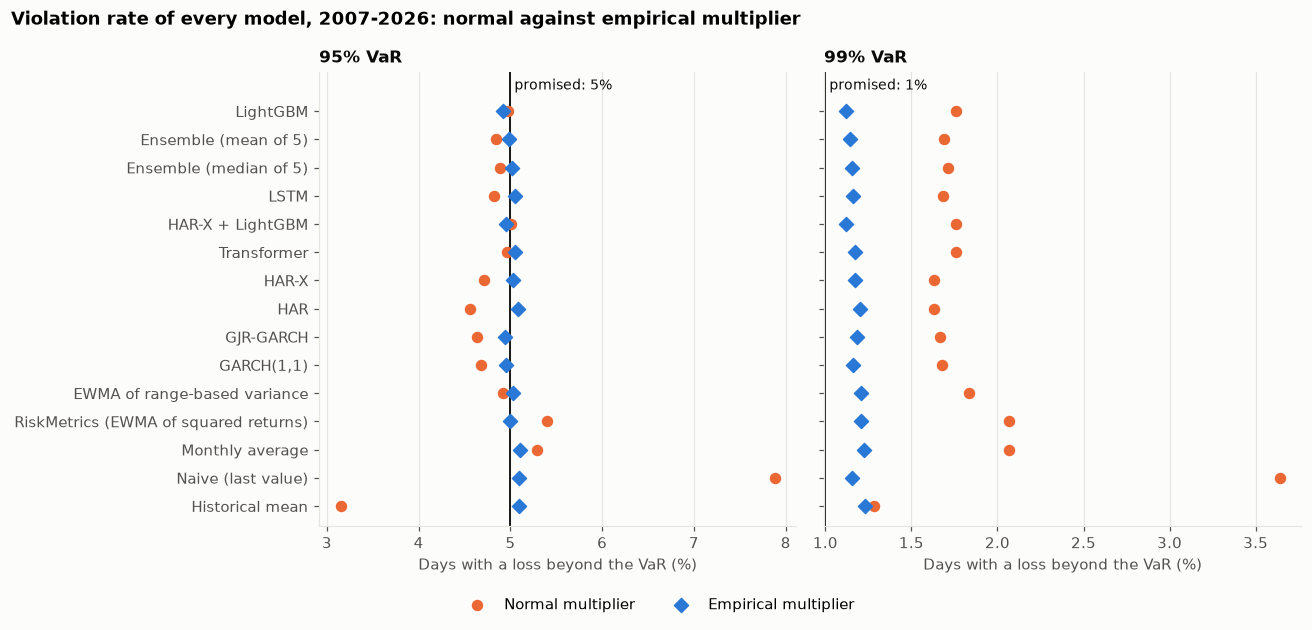

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharey=True)
order = ranking[::-1]
for ax, confidence in zip(axes, [95, 99]):
    expected = 100 - confidence
    for method, color, marker in [("normal", ORANGE, "o"), ("empirical", BLUE, "D")]:
        rate = results(method, confidence, benchmark=False).loc[order, "violation_rate"] * 100
        ax.scatter(rate.values, range(len(order)), color=color, marker=marker, s=42, zorder=3,
                   label={"normal": "Normal multiplier", "empirical": "Empirical multiplier"}[method])
    ax.axvline(expected, color=INK, lw=1.2)
    ax.text(expected, len(order) - 0.35, f" promised: {expected}%", color=INK, fontsize=9, va="bottom")
    ax.set_yticks(range(len(order)), [LABELS[m] for m in order])
    ax.set_ylim(-0.7, len(order) + 0.4)
    ax.set_xlabel("Days with a loss beyond the VaR (%)")
    ax.set_title(f"{confidence}% VaR", fontsize=11)
    ax.grid(axis="y", visible=False)
handles, names = axes[1].get_legend_handles_labels()
fig.legend(handles, names, loc="lower center", ncols=2, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Violation rate of every model, 2007-2026: normal against empirical multiplier", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 1))
save(fig, "10_coverage")
plt.show()

**Reading the results.**

* **The level of volatility is right.** Standardised returns have a standard deviation of 1.00 to 1.02 for the good models (1.07 for RiskMetrics): on average the forecasts are neither too high nor too low.
* **But the tails are fat.** The 1% worst standardised return is at -2.7, not -2.33, and a move beyond four volatilities is about 70 times more frequent than under the normal distribution (0.22% of the days against 0.003%).
* **At 95% the normal multiplier works; at 99% it fails for every model.** At 95%, the models from GARCH to the combinations have 4.6 to 5.0% of violations: the 5% quantile of standardised returns (about -1.6) is almost the normal one (-1.645). At 99%, the best models have 1.6 to 1.8% of violations, two thirds to three quarters more than promised. The empirical multiplier brings all of them back to 1.1-1.2%.

This is the "fat tails" finding of the exploratory analysis at work: forecasting volatility well does not make returns normal. The further into the tail, the more it matters.

## 3. Is the number of violations right? The Kupiec test

A violation rate of 1.2% instead of 1% may be bad luck or a real flaw. The **Kupiec test** (also called the proportion-of-failures test) decides: given the number of days, how likely is a gap this large if the VaR were correct? Its **p-value** is that probability. Below 0.05, the VaR **fails** the test.

The test is run **series by series** (59 tests per model), because the violations of different stocks on the same day are not independent: pooling 290,000 observations would make the smallest gap look significant. The table gives the overall violation rate and the share of the 59 series that pass.

In [ ]:
def coverage_table(confidence):
    columns = {}
    for method in ["normal", "empirical"]:
        r = results(method, confidence)
        columns[(method, "violations (%)")] = r["violation_rate"] * 100
        columns[(method, "series passing Kupiec (%)")] = r["pass_kupiec"] * 100
    table = pd.DataFrame(columns).loc[ranking + [HS]]
    table.loc[HS, "normal"] = np.nan                             # the benchmark has no multiplier: shown once
    return table.rename(index=LABELS)

for confidence in [99, 95]:
    print(f"{confidence}% VaR (promised: {100 - confidence}% of violations)")
    display(coverage_table(confidence).round(2))

99% VaR (promised: 1% of violations)


normal                                empirical                          
                                            violations (%) series passing Kupiec (%) violations (%) series passing Kupiec (%)
model                                                                                                                        
LightGBM                                              1.76                      8.47           1.12                     86.44
Ensemble (mean of 5)                                  1.69                     15.25           1.14                     81.36
Ensemble (median of 5)                                1.71                     13.56           1.16                     77.97
LSTM                                                  1.68                     16.95           1.16                     83.05
HAR-X + LightGBM                                      1.76                     10.17           1.12                     81.36
Transformer                                           1.76                     11.86           1.17                     74.58
HAR-X                                                 1.63                     15.25           1.17                     79.66
HAR                                                   1.63                     13.56           1.20                     74.58
GJR-GARCH                                             1.66                      5.08           1.18                     76.27
GARCH(1,1)                                            1.68                      3.39           1.16                     79.66
EWMA of range-based variance                          1.84                      6.78           1.20                     71.19
RiskMetrics (EWMA of squared returns)                 2.07                      0.00           1.21                     76.27
Monthly average                                       2.06                      1.69           1.22                     71.19
Naive (last value)                                    3.64                      0.00           1.16                     79.66
Historical mean                                       1.28                     33.90           1.23                     66.10
Historical simulation (no volatility model)            NaN                       NaN           1.61                      0.00

95% VaR (promised: 5% of violations)


normal                                empirical                          
                                            violations (%) series passing Kupiec (%) violations (%) series passing Kupiec (%)
model                                                                                                                        
LightGBM                                              4.97                     49.15           4.92                     89.83
Ensemble (mean of 5)                                  4.85                     42.37           4.99                     91.53
Ensemble (median of 5)                                4.89                     44.07           5.01                     93.22
LSTM                                                  4.82                     40.68           5.05                     91.53
HAR-X + LightGBM                                      5.01                     49.15           4.95                     93.22
Transformer                                           4.97                     45.76           5.05                     94.92
HAR-X                                                 4.71                     42.37           5.03                     89.83
HAR                                                   4.56                     49.15           5.08                     91.53
GJR-GARCH                                             4.63                     55.93           4.94                     98.31
GARCH(1,1)                                            4.67                     59.32           4.95                     96.61
EWMA of range-based variance                          4.92                     52.54           5.02                     93.22
RiskMetrics (EWMA of squared returns)                 5.40                     62.71           4.99                    100.00
Monthly average                                       5.29                     62.71           5.10                     94.92
Naive (last value)                                    7.88                      0.00           5.09                     89.83
Historical mean                                       3.15                      8.47           5.10                     66.10
Historical simulation (no volatility model)            NaN                       NaN           5.71                     22.03

**Reading the results.**

* **Normal multiplier, 99%:** from GARCH to the combinations, at most 17% of the series pass. The formula is rejected almost everywhere.
* **Empirical multiplier:** for the same models, 75 to 86% of the series pass at 99% and 90 to 98% at 95% (a perfect VaR would pass for 95% of them). At 99% a small excess remains (1.12 to 1.23% of violations instead of 1%): the multiplier is learned from the past, and a crisis worse than anything seen before produces more violations than the past could announce.
* **The Kupiec test does not rank the models.** Once the multiplier is learned from the data, even the naive forecast passes for 80% of the series: a poor forecast is compensated by a larger multiplier. Counting violations tells whether a VaR is *honest*, not whether it is *good*.
* **Only historical simulation fails outright:** 1.61% of violations at 99%, and not one series out of 59 passes the test.

## 4. Same number of violations, different quality

The right number of violations is not enough. A VaR of 50% every day would never be violated, and would be useless: it would freeze all the capital. Among VaRs that keep their promise, the better one is the one that is **smaller on calm days and larger on dangerous days**.

The **quantile loss** measures this in one number. On a normal day it charges a small fee proportional to the distance between the return and the VaR (capital left idle); on a violation it charges a large fee proportional to the amount by which the loss exceeded the VaR. Its average is lowest for the VaR that tracks risk best. It is expressed here in basis points (1 basis point = 0.01%) of the position.

The differences are tested with the Diebold-Mariano test of Step 9, against HAR-X with the same multiplier. HAR-X stays the reference for the same reasons as in Step 9 (notebook 08, section 2): it is the best model without machine learning, the advanced models start from the same information, and it is the simple model that a complex one has to beat. The reference only sets the unit of the comparison: the ranking is the one of the raw quantile loss.

In [ ]:
def stars(p):
    return "" if pd.isna(p) else "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

def quality_table(confidence, method="empirical"):
    r = results(method, confidence)
    t = tests[(tests["confidence"] == confidence) & (tests["method"].isin([method, "historical"]))].set_index("model")
    table = pd.DataFrame({"violations (%)": r["violation_rate"] * 100, "average VaR (%)": r["mean_var"] * 100,
                          "quantile loss (bp)": r["quantile_loss"] * 1e4,
                          "vs HAR-X": [f"{d:+.1%}{stars(p)}" for d, p in zip(t.loc[r.index, "loss_vs_reference"], t.loc[r.index, "p_value"])]})
    return table.rename(index=LABELS)

for confidence in [99, 95]:
    print(f"{confidence}% VaR, empirical multiplier   (*** p < 0.01, ** p < 0.05, * p < 0.10)")
    display(quality_table(confidence))

99% VaR, empirical multiplier   (*** p < 0.01, ** p < 0.05, * p < 0.10)


,violations (%),average VaR (%),quantile loss (bp),vs HAR-X
model,,,,
LightGBM,1.12,4.31,5.91,-1.2%
Ensemble (mean of 5),1.14,4.30,5.94,-0.9%**
Ensemble (median of 5),1.16,4.28,5.94,-0.8%***
LSTM,1.16,4.32,5.94,-0.7%
HAR-X + LightGBM,1.12,4.34,5.95,-0.6%*
Transformer,1.17,4.28,5.97,-0.4%
HAR-X,1.17,4.30,5.99,+0.0%
HAR,1.20,4.33,6.08,+1.5%***
GJR-GARCH,1.18,4.40,6.16,+3.0%***


95% VaR, empirical multiplier   (*** p < 0.01, ** p < 0.05, * p < 0.10)


,violations (%),average VaR (%),quantile loss (bp),vs HAR-X
model,,,,
Ensemble (mean of 5),4.99,2.70,19.12,-0.3%**
Ensemble (median of 5),5.01,2.70,19.13,-0.3%***
LightGBM,4.92,2.71,19.14,-0.2%
HAR-X + LightGBM,4.95,2.72,19.17,-0.1%
LSTM,5.05,2.71,19.17,-0.0%
Transformer,5.05,2.70,19.17,-0.0%
HAR-X,5.03,2.70,19.18,+0.0%
HAR,5.08,2.70,19.38,+1.0%***
GJR-GARCH,4.94,2.72,19.52,+1.8%***


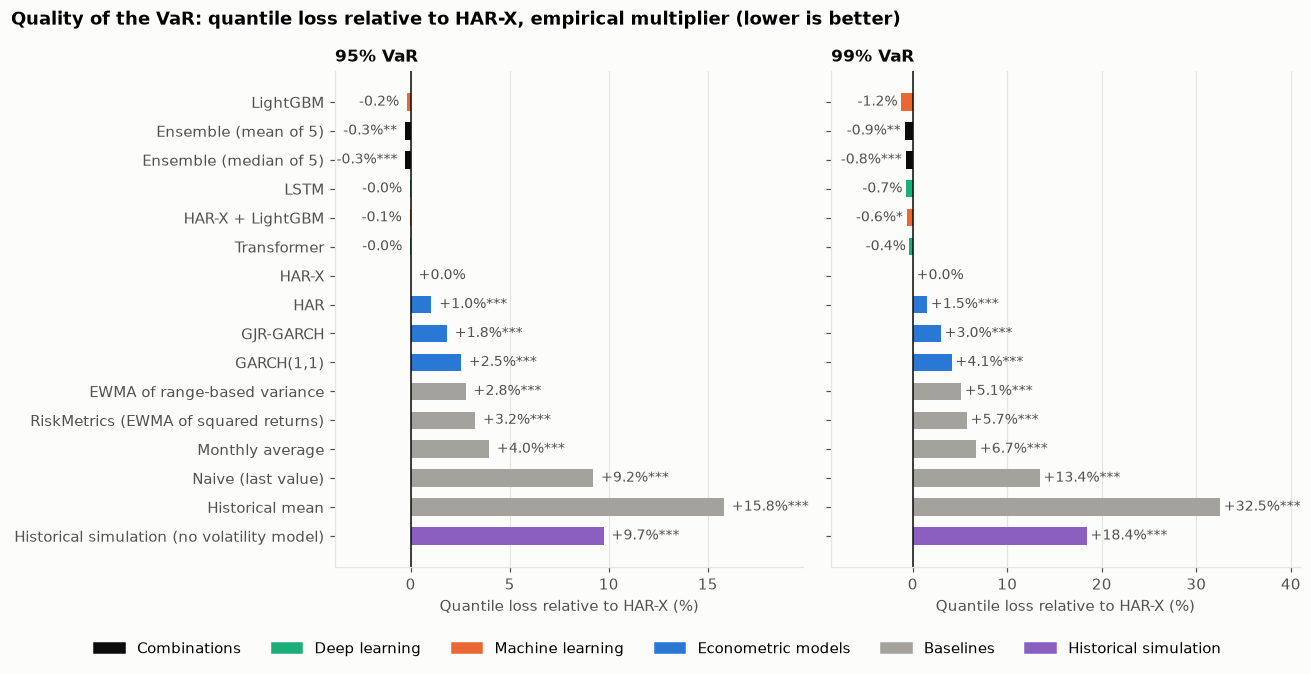

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
order = (ranking + [HS])[::-1]
family = overall.drop_duplicates("model").set_index("model")["family"]
for ax, confidence in zip(axes, [95, 99]):
    t = tests[(tests["confidence"] == confidence) & (tests["method"] != "normal")].set_index("model").loc[order]
    relative = t["loss_vs_reference"] * 100
    ax.barh(range(len(order)), relative.values, color=[FAMILIES[family[m]][1] for m in order], height=0.6)
    for y, (value, p) in enumerate(zip(relative.values, t["p_value"])):
        ax.text(value + (0.4 if value >= 0 else -0.4), y, f"{value:+.1f}%{stars(p)}", va="center",
                ha="left" if value >= 0 else "right", color=INK_2, fontsize=9)
    ax.axvline(0, color=INK, lw=1)
    ax.set_yticks(range(len(order)), [LABELS[m] for m in order])
    span = relative.max() - min(relative.min(), 0)
    ax.set_xlim(min(relative.min(), 0) - 0.22 * span, relative.max() + 0.25 * span)
    ax.set_xlabel("Quantile loss relative to HAR-X (%)")
    ax.set_title(f"{confidence}% VaR", fontsize=11)
    ax.grid(axis="y", visible=False)
used = [f for f in FAMILIES if f in set(family[order])]
fig.legend([plt.Rectangle((0, 0), 1, 1, color=FAMILIES[f][1]) for f in used], [FAMILIES[f][0] for f in used],
           loc="lower center", ncols=len(used), bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Quality of the VaR: quantile loss relative to HAR-X, empirical multiplier (lower is better)",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 1))
save(fig, "10_quantile_loss")
plt.show()

**Reading the results.**

* **Same protection, different cost.** The naive forecast and HAR-X have almost the same number of violations at 99% (1.16% and 1.17%), but the naive VaR is 5.30% of the position on average against 4.30%: 23% more capital for the same protection.
* **The ranking is the one of Step 9.** Baselines, then GARCH, then HAR, then HAR-X and the more complex models: the statistical loss (QLIKE) was a good guide to the practical use.
* **Using a volatility model at all is the big step.** At 99%, going from historical simulation to RiskMetrics, the simplest volatility model, lowers the quantile loss by 11%; going on to HAR-X lowers it by a further 5%.
* **Beyond HAR-X the gains are small.** They are below 1.3%, and only the combinations are significantly better than HAR-X (-0.9% and -0.8% at 99%, -0.3% at 95%). LightGBM has the lowest loss at 99% (-1.2%), but the difference is too irregular from day to day to be significant.

The conclusion of the model comparison carries over to risk management: information and measurement matter, the choice of the algorithm hardly does, and combining models is the one reliable improvement.

## 5. Do violations come in clusters?

Ten violations spread over a year and ten violations in two weeks are the same number, but not the same risk: the second case can bring a bank down. If a VaR reacts to new information, a violation today should not make a violation tomorrow more likely.

The **Christoffersen independence test** compares the frequency of violations on the day after a violation with the frequency on the other days. A p-value below 0.05 means that violations cluster. The **conditional coverage** test combines it with the Kupiec test: right number *and* no clustering.

In [ ]:
def clustering_table(confidence):
    r = results("empirical", confidence)
    table = pd.DataFrame({"Kupiec (right number)": r["pass_kupiec"] * 100, "Independence (no clustering)": r["pass_independence"] * 100,
                          "Conditional coverage (both)": r["pass_cond_coverage"] * 100}).loc[ranking + [HS]]
    return table.rename(index=LABELS)

for confidence in [99, 95]:
    print(f"{confidence}% VaR, empirical multiplier: share of the 59 series passing each test (%)")
    display(clustering_table(confidence).round(0))

99% VaR, empirical multiplier: share of the 59 series passing each test (%)


,Kupiec (right number),Independence (no clustering),Conditional coverage (both)
model,,,
LightGBM,86.00,98.00,97.00
Ensemble (mean of 5),81.00,98.00,86.00
Ensemble (median of 5),78.00,98.00,83.00
LSTM,83.00,98.00,86.00
HAR-X + LightGBM,81.00,98.00,90.00
Transformer,75.00,97.00,85.00
HAR-X,80.00,95.00,81.00
HAR,75.00,95.00,73.00
GJR-GARCH,76.00,95.00,80.00


95% VaR, empirical multiplier: share of the 59 series passing each test (%)


,Kupiec (right number),Independence (no clustering),Conditional coverage (both)
model,,,
LightGBM,90.00,92.00,90.00
Ensemble (mean of 5),92.00,85.00,81.00
Ensemble (median of 5),93.00,85.00,80.00
LSTM,92.00,83.00,81.00
HAR-X + LightGBM,93.00,86.00,81.00
Transformer,95.00,83.00,81.00
HAR-X,90.00,80.00,80.00
HAR,92.00,58.00,69.00
GJR-GARCH,98.00,69.00,85.00


The same question seen year by year: the violation rate of the 99% VaR of each model in each year (all series together). The promise is 1% every year. Blue means fewer violations than promised, orange more; rates of 2% or more are written out.

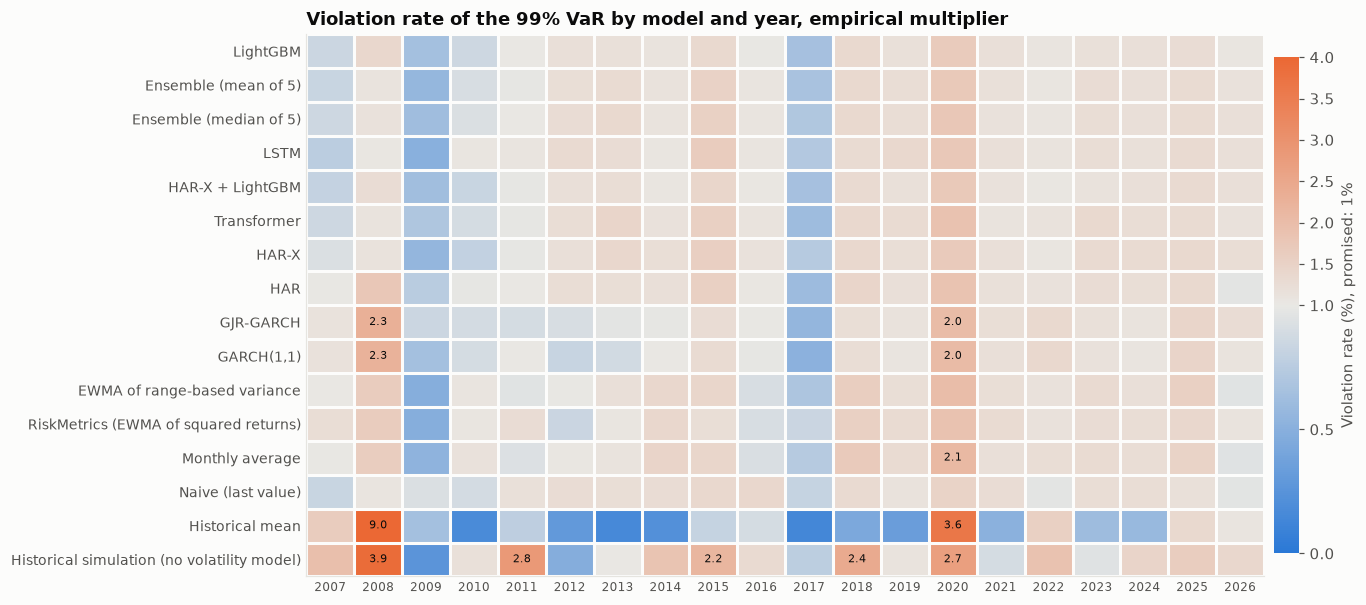

,worst year,rate that year (%),years above 1.5%
model,,,
LightGBM,2020,1.66,1
Ensemble (mean of 5),2020,1.73,2
Ensemble (median of 5),2020,1.77,2
LSTM,2020,1.74,2
HAR-X + LightGBM,2020,1.72,1
Transformer,2020,1.89,2
HAR-X,2020,1.69,2
HAR,2020,1.85,3
GJR-GARCH,2008,2.31,2


In [ ]:
by_year = (yearly[(yearly["confidence"] == 99) & (yearly["method"] != "normal")]
           .groupby(["model", "year"])[["violations", "n"]].sum())
rate = (by_year["violations"] / by_year["n"] * 100).unstack("year").loc[ranking + [HS]]

fig, ax = plt.subplots(figsize=(12.5, 5.6))
image = ax.imshow(rate.to_numpy(), cmap=DIVERGING, norm=TwoSlopeNorm(vmin=0, vcenter=1, vmax=4), aspect="auto")
ax.set_xticks(range(rate.shape[1]), rate.columns, fontsize=8)
ax.set_yticks(range(rate.shape[0]), [LABELS[m] for m in rate.index], fontsize=9)
ax.set_xticks(np.arange(-0.5, rate.shape[1]), minor=True)
ax.set_yticks(np.arange(-0.5, rate.shape[0]), minor=True)
ax.grid(False)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="both", length=0)
for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        if rate.iat[i, j] >= 2:
            ax.text(j, i, f"{rate.iat[i, j]:.1f}", ha="center", va="center", fontsize=7, color=INK)
colorbar = fig.colorbar(image, ax=ax, pad=0.01, fraction=0.025)
colorbar.set_label("Violation rate (%), promised: 1%")
colorbar.outline.set_visible(False)
ax.set_title("Violation rate of the 99% VaR by model and year, empirical multiplier")
fig.tight_layout()
save(fig, "10_violations_by_year")
plt.show()

summary = pd.DataFrame({"worst year": rate.idxmax(axis=1), "rate that year (%)": rate.max(axis=1),
                        "years above 1.5%": (rate > 1.5).sum(axis=1)})
display(summary.rename(index=LABELS).round(2))

**Reading the results.**

* **At 99%, the seven models that use the full feature set pass the independence test for 95 to 98% of the series.** The slow baselines do not: 58% for the EWMA, 53% for the monthly average, 31% for historical simulation, 17% for the historical mean.
* **At 95%, where violations are five times as numerous and the test sees more, the good models separate:** 92% for LightGBM, 80 to 86% for the others with the full feature set, but 58% for HAR, 53% for GARCH, 17% for the EWMA and 3% for historical simulation. The extra information of HAR-X (market-wide volatility, VIX, recent falls) is what makes a VaR react in time: from 58% to 80%.
* **The naive forecast passes** because it forgets everything except yesterday: it reacts at once, and pays for it with a VaR that is 23% larger.

**Year by year.** For the models from HAR-X upwards, the worst year is 2020 with 1.7 to 1.9% of violations, and at most two years out of twenty are above 1.5%. The GARCH models have their worst year in 2008 (2.3%): estimated one series at a time, they cannot see that the whole market is under stress. Historical simulation reaches 3.9% in 2008 and is above 1.5% in nine years out of twenty. The blue columns (2009, 2017) are the opposite error, a VaR larger than needed: costly in capital, but not dangerous.

## 6. What would the regulator say? The Basel traffic light

Banking supervisors backtest a bank's internal model with a simple rule (Basel Committee, 1996): count the violations of the 99% VaR over the last 250 trading days.

| Zone | Violations in 250 days | Consequence |
|---|---|---|
| **Green** | 0 to 4 | Model accepted |
| **Yellow** | 5 to 9 | Capital requirement increased |
| **Red** | 10 or more | Model presumed wrong |

Here the rule is applied to every series and every full calendar year: about 1,100 "series-years" per model. Even a correct model has five violations or more in some years by bad luck alone: it lands in the green zone slightly less than 9 times out of 10, in the yellow zone otherwise, and practically never in the red zone.

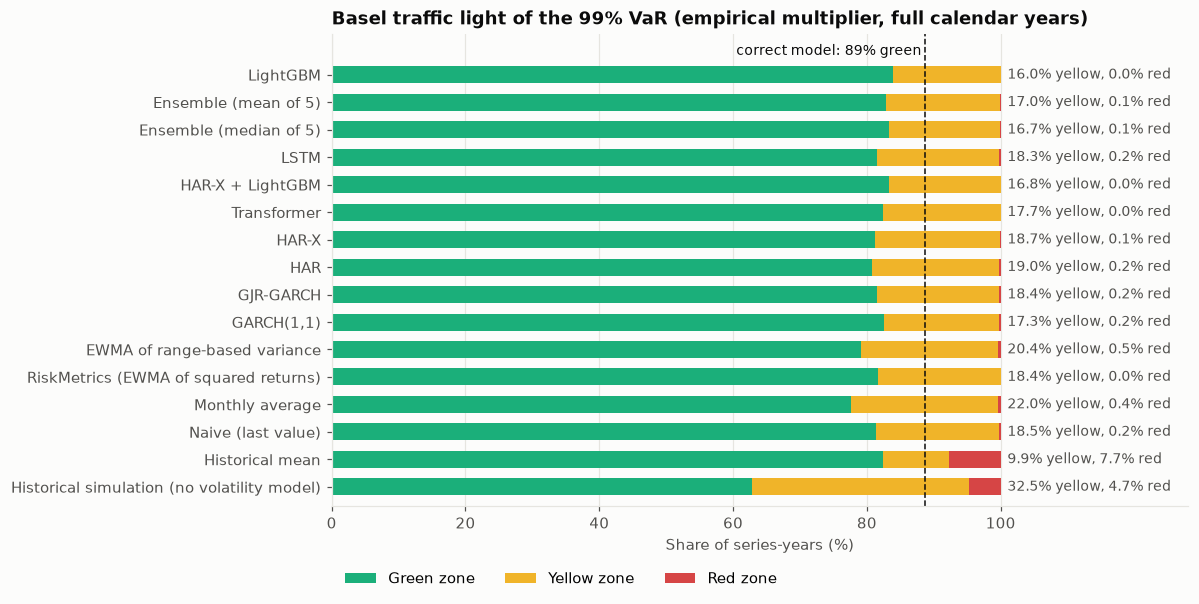

Series-years per model: 1,110; a correct VaR would be in the green zone 88.8% of the time
Share of series-years outside the green zone (%): normal against empirical multiplier


,normal multiplier,empirical multiplier
model,,
LightGBM,44.30,16.00
Ensemble (mean of 5),41.30,17.10
Ensemble (median of 5),42.60,16.80
LSTM,41.20,18.50
HAR-X + LightGBM,44.30,16.80
Transformer,43.60,17.70
HAR-X,40.00,18.80
HAR,41.20,19.20
GJR-GARCH,40.70,18.60


In [ ]:
full_years = yearly[(yearly["confidence"] == 99) & (yearly["n"] >= 240)]

def zones(method):
    rows = full_years[full_years["method"].isin([method, "historical"])]
    share = rows.groupby("model")["zone"].value_counts(normalize=True).unstack(fill_value=0) * 100
    return share.reindex(columns=["green", "yellow", "red"], fill_value=0).loc[ranking + [HS]]

# Share of green years that a correct VaR would get, given the number of trading days of each series-year
days = full_years.drop_duplicates(["ticker", "year"])["n"].to_numpy()
green_limit = np.array([max(x for x in range(12) if binom.cdf(x, n, 0.01) < 0.95) for n in days])
expected_green = binom.cdf(green_limit, days, 0.01).mean() * 100

share = zones("empirical")
fig, ax = plt.subplots(figsize=(11, 5.6))
order = share.index[::-1]
left = np.zeros(len(order))
for zone, color in [("green", AQUA), ("yellow", "#f0b429"), ("red", "#d64545")]:
    values = share.loc[order, zone].to_numpy()
    ax.barh(range(len(order)), values, left=left, color=color, height=0.62, label=f"{zone.capitalize()} zone")
    left += values
for y, model in enumerate(order):
    ax.text(101, y, f"{share.loc[model, 'yellow']:.1f}% yellow, {share.loc[model, 'red']:.1f}% red", va="center", fontsize=9, color=INK_2)
ax.axvline(expected_green, color=INK, lw=1, ls="--")
ax.text(expected_green, len(order) - 0.4, f"correct model: {expected_green:.0f}% green ", ha="right", va="bottom", fontsize=9, color=INK)
ax.set_yticks(range(len(order)), [LABELS[m] for m in order])
ax.set_xlim(0, 128)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_ylim(-0.7, len(order) + 0.5)
ax.set_xlabel("Share of series-years (%)")
ax.set_title("Basel traffic light of the 99% VaR (empirical multiplier, full calendar years)")
ax.legend(loc="lower left", ncols=3, bbox_to_anchor=(0, -0.2))
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "10_traffic_light")
plt.show()

print(f"Series-years per model: {len(days):,}; a correct VaR would be in the green zone {expected_green:.1f}% of the time")
print("Share of series-years outside the green zone (%): normal against empirical multiplier")
outside = pd.DataFrame({"normal multiplier": 100 - zones("normal")["green"], "empirical multiplier": 100 - zones("empirical")["green"]})
outside.loc[HS, "normal multiplier"] = np.nan
display(outside.rename(index=LABELS).round(1))

**Reading the results.**

* **The best models are close to what a correct VaR would get.** A correct VaR is outside the green zone 11% of the time by bad luck alone; LightGBM, the combinations and HAR-X are outside 16 to 19% of the time, and in the red zone practically never (0.2% of the series-years at most). The excess of yellow years comes from the crisis years.
* **Historical simulation would be in trouble:** outside the green zone 37% of the time, and in the red zone 4.7% of the time, about 50 series-years out of 1,110.
* **The multiplier matters more than the model.** With the normal multiplier, the good models are outside the green zone 40 to 45% of the time, almost four times the rate of a correct VaR: a bank using the textbook formula would pay a capital add-on almost every other year. Switching to the empirical multiplier (from 41% to 17% for the combination) changes far more than switching between good models (16 to 19%).

## 7. Is the most accurate model the safest one in a crisis?

Step 8 found that the model with the smallest average error (the Transformer) was not the best on QLIKE, the loss that punishes forecasts that are too low, and that each network had one bad crisis year. A VaR is exactly the situation where a forecast that is too low costs the most.

The table gives the violation rate of the 99% VaR in the three most turbulent years of the sample and over the whole period. With the **normal multiplier** the VaR is the raw forecast times 2.33: any tendency to under-predict shows directly. With the **empirical multiplier** the average level has been corrected on past data; what remains is the ability to raise the forecast in time.

In [ ]:
crisis_years = [2008, 2020, 2022]
shown = ["ensemble_mean", "har_x", "lgbm_hybrid", "lgbm", "lstm", "transformer", "gjr_garch", "riskmetrics", HS]

def crisis_table(method):
    rows = yearly[(yearly["confidence"] == 99) & (yearly["method"].isin([method, "historical"]))]
    by = rows.groupby(["model", "year"])[["violations", "n"]].sum()
    table = (by["violations"] / by["n"] * 100).unstack("year")[crisis_years]
    total = rows.groupby("model")[["violations", "n"]].sum()
    table["all years"] = total["violations"] / total["n"] * 100
    return table.loc[shown].rename(index=LABELS)

for method in ["normal", "empirical"]:
    print(f"Violation rate of the 99% VaR (%), {method} multiplier (promised: 1%)")
    display(crisis_table(method).round(2))

size = yearly[(yearly["confidence"] == 99) & (yearly["method"] != "normal") & (yearly["year"].isin(crisis_years))]
size = size.assign(total=size["mean_var"] * size["n"]).groupby(["model", "year"])[["total", "n"]].sum()
size = (size["total"] / size["n"] * 100).unstack("year")
print("Average size of the 99% VaR in those years (% of the position), empirical multiplier")
display(size.loc[shown].rename(index=LABELS).round(2))

Violation rate of the 99% VaR (%), normal multiplier (promised: 1%)


year,2008,2020,2022,all years
model,,,,
Ensemble (mean of 5),1.91,2.36,1.75,1.69
HAR-X,1.79,2.31,1.55,1.63
HAR-X + LightGBM,2.26,2.40,1.73,1.76
LightGBM,2.34,2.34,1.76,1.76
LSTM,1.78,2.34,1.79,1.68
Transformer,1.87,2.58,1.91,1.76
GJR-GARCH,2.65,2.57,1.93,1.66
RiskMetrics (EWMA of squared returns),2.65,2.84,2.21,2.07
Historical simulation (no volatility model),3.88,2.70,1.88,1.61


Violation rate of the 99% VaR (%), empirical multiplier (promised: 1%)


year,2008,2020,2022,all years
model,,,,
Ensemble (mean of 5),1.10,1.73,1.06,1.14
HAR-X,1.12,1.69,1.06,1.17
HAR-X + LightGBM,1.26,1.72,1.02,1.12
LightGBM,1.38,1.66,1.09,1.12
LSTM,1.03,1.74,1.11,1.16
Transformer,1.10,1.89,1.12,1.17
GJR-GARCH,2.31,2.02,1.35,1.18
RiskMetrics (EWMA of squared returns),1.65,1.87,1.15,1.21
Historical simulation (no volatility model),3.88,2.70,1.88,1.61


Average size of the 99% VaR in those years (% of the position), empirical multiplier


year,2008,2020,2022
model,,,
Ensemble (mean of 5),7.73,5.72,4.87
HAR-X,7.72,5.79,4.99
HAR-X + LightGBM,7.56,5.82,4.94
LightGBM,7.27,5.75,4.93
LSTM,8.15,5.68,4.78
Transformer,7.88,5.65,4.78
GJR-GARCH,6.68,5.81,4.88
RiskMetrics (EWMA of squared returns),7.51,6.38,5.21
Historical simulation (no volatility model),5.61,6.37,4.93


**Reading the results: the finding of Step 8 is confirmed, and the effect is modest.**

* **The Transformer is the least safe of the advanced models when markets break.** With the normal multiplier (the raw forecast), it has the most violations in 2020 (2.58% against 2.31% for HAR-X), in 2022 (1.91% against 1.55%) and over the whole period (1.76% against 1.63%), although it had the smallest average error in Step 8. With the empirical multiplier, which corrects the average level, the gap of 2020 remains (1.89% against 1.69% for HAR-X and 1.66% for LightGBM): its VaR was the smallest of the group that year (5.65% of the position against 5.79%).
* **The LSTM was the most cautious in 2008:** the largest VaR (8.15%) and 1.03% of violations, almost exactly the promise, in the worst year of the sample.
* **GJR-GARCH had the smallest model-based VaR in 2008** (6.68%) and more than twice the promised violations (2.31%).
* **Historical simulation prepares for the last crisis, not the next one:** the smallest VaR of all in 2008 (5.61%, with 3.88% of violations), one of the largest in 2020 (6.37%) and still 2.70% of violations, because it rises after the losses have happened.
* **The combination is never the worst and always close to the best:** 1.10% in 2008, 1.73% in 2020, 1.06% in 2022.

**No model kept the promise in 2020** (1.7% at best). A crash that starts from a calm market and unfolds in a few days cannot be forecast from past prices. A good volatility model limits the damage; it does not remove the surprise.

## Summary

**Do better volatility forecasts make better risk limits? Yes, and the practical ranking is the statistical one.**

99% VaR with the empirical multiplier, 2007 to 2026:

| | Violations (promised: 1%) | Series passing Kupiec | Series without clustering | Average VaR | Quantile loss vs HAR-X | Series-years outside the green zone |
|---|---|---|---|---|---|---|
| Historical simulation (no volatility model) | 1.61% | 0% | 31% | 4.45% | +18.4% | 37% |
| RiskMetrics | 1.21% | 76% | 85% | 4.53% | +5.7% | 18% |
| GJR-GARCH | 1.18% | 76% | 95% | 4.40% | +3.0% | 19% |
| HAR-X | 1.17% | 80% | 95% | 4.30% | reference | 19% |
| **Ensemble (mean of 5)** | **1.14%** | **81%** | **98%** | **4.30%** | **-0.9%** (significant) | **17%** |

* **Returns have fat tails, whatever the model.** The textbook normal multiplier is acceptable at 95% and fails at 99% for every model (1.6 to 1.8% of violations). The multiplier has to be learned from the data.
* **Any volatility model beats historical simulation by a wide margin:** fewer violations, far less clustering, and half as many years outside the regulator's green zone.
* **A better forecast buys the same protection with less capital.** With a learned multiplier almost any forecast gets the right number of violations; the good ones get it with a smaller VaR (4.30% against 5.30% for the naive forecast) and without clusters.
* **Beyond HAR-X the gains are below 1.3%,** and only the forecast combinations are significantly better: the same verdict as in the model comparison.
* **Counting violations is not enough.** The Kupiec test cannot tell a good VaR from a merely honest one; the quantile loss and the independence test can.
* **The most accurate model on average is not the safest:** the Transformer has the most violations of the advanced models in 2020 and 2022.

**Recommendation.** VaR = empirical multiplier (re-estimated each year, per series) × the volatility forecast of the combination, or of HAR-X alone if a single simple model is preferred.

**Limits.** One-day horizon only. Each stock or index is treated on its own: a portfolio VaR also needs correlations. Expected Shortfall (the average loss beyond the VaR), which the most recent Basel rules use to set capital, is not covered. Series with less than three years of history share the multiplier of all series.

Next: Step 11 turns the results stored in PostgreSQL into a Power BI dashboard.